In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

from System.system import System, Agent

In [2]:
def identity(arr):
    return arr

# Refactored Code

## System_01 - 1D Flipflop

In [3]:
sys_01 = System(np.array([[0.0],[1.0]]),
                ((identity, [1]), (identity, [0])),
               verbose=True)
sys_01.go(10)

input chan idxs: []


array([[[0.],
        [1.]],

       [[1.],
        [0.]],

       [[0.],
        [1.]],

       [[1.],
        [0.]],

       [[0.],
        [1.]],

       [[1.],
        [0.]],

       [[0.],
        [1.]],

       [[1.],
        [0.]],

       [[0.],
        [1.]],

       [[1.],
        [0.]]])

## System_02 - 3D Flipflop

In [4]:
sys_02 = System(np.array([[0.0,1.0,0.0],[1.0,1.0,0.0]]),
                ((identity, [1]), (identity, [0])),
               verbose=True)
sys_02.go(10)

input chan idxs: []


array([[[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]],

       [[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]],

       [[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]],

       [[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]],

       [[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]]])

## System_03 - 3D Multi-system Queue

In [5]:
sys_03a = System(np.array([[0.0,0.0,0.0],[0.0,0.0,0.0],[0.0,0.0,0.0],[0.0,0.0,0.0]]),
                (None, (identity, [0]), (identity, [1]), (identity, [2])),
                output_channel_idx=3,
                verbose=True)

sys_03b = System(np.array([[0.0,0.0,0.0],[0.0,0.0,0.0],[0.0,0.0,0.0],[0.0,0.0,0.0]]),
                ((None), (identity, [0]), (identity, [1]), (identity, [2])),
                output_channel_idx=3,
                verbose=True)

sys_03c = System(np.array([[0.0,2.0,0.0],[1.0,1.0,0.0]]),
                ((sys_03a, [1]), (sys_03b, [0])),
               verbose=True)
sys_03c.go(10)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


array([[[0., 2., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 2., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 2., 0.]],

       [[1., 1., 0.],
        [0., 2., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 2., 0.],
        [0., 0., 0.],
        [1., 1., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 2., 0.],
        [0., 0., 0.],
        [1., 1., 0.]],

       [[0., 2., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 0

## System_04 - (Conformist) Agent with Plant (n=1)

In [3]:
np.random.seed(31415926)
n = 1

l_val = 1.0
a_val=0.4

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n) 
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    # if ref_bounds is not None:
    #     reference[reference > ref_bounds[1]] = ref_bounds[1]
    #     reference[reference < ref_bounds[0]] = ref_bounds[0]
    return reference
def feedback_false(error, reference, reference_init):
    return reference

# SYSTEM INIT
sys_04a = Agent(sense, compare, effect, move, feedback,
                n, reference_initial=np.full((1,n), 0.75),
                verbose=True)

 # -------------------------------------- #

# PLANT

T_scaler = 0.1
transition_matrix = np.random.rand(n,n) * T_scaler 
def plant_control(control_signal, state):
    output = control_signal @ transition_matrix + state
    return output
    
def plant_reflect(control_signal, state):
    output = control_signal @ transition_matrix
    return output

# SYSTEM INIT
sys_04b = System(np.zeros((2,n)),
                ((None), (plant_control, [0,1])),
                ["plant input", "plant output"],
                output_channel_idx=1,
                verbose=True)

 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_04c = System(np.random.rand(2,n),
                ((sys_04b, [1]), (sys_04a, [0])),
                ["agent input / plant behavior", "plant input / motor signal"],
               verbose=True)
sysout = sys_04c.go(1000)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


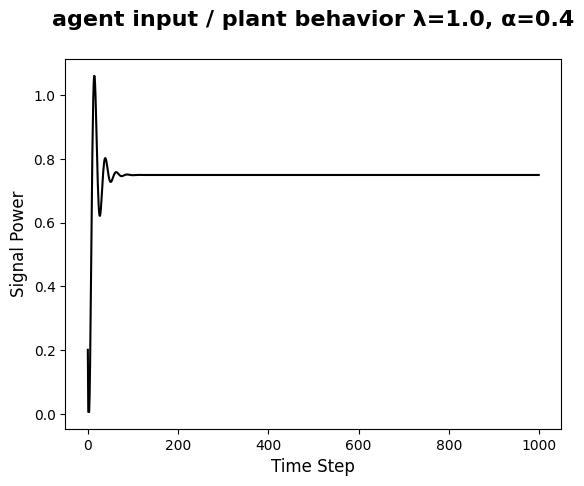

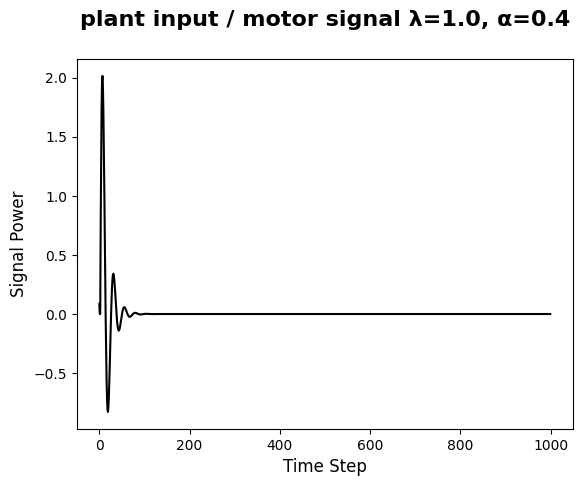

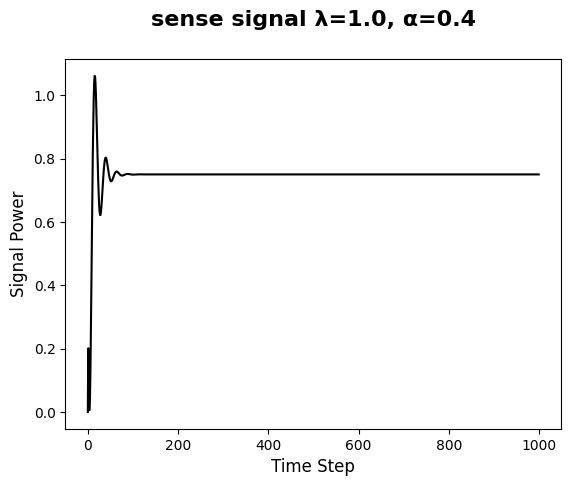

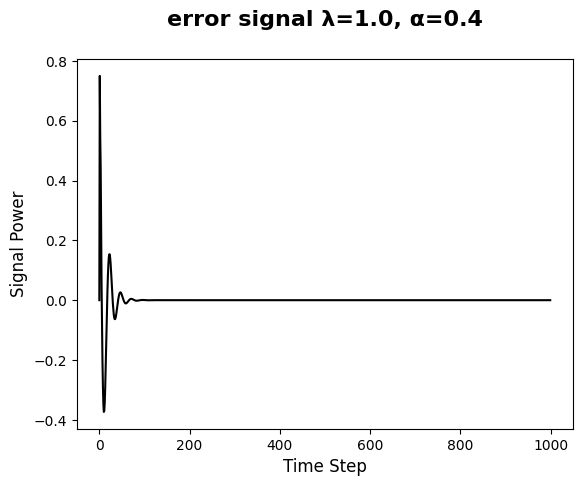

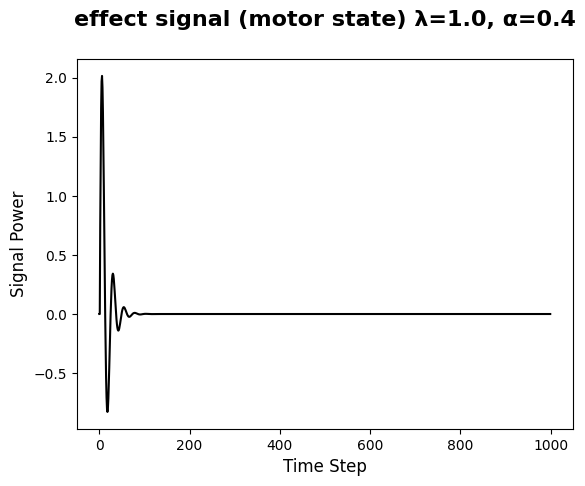

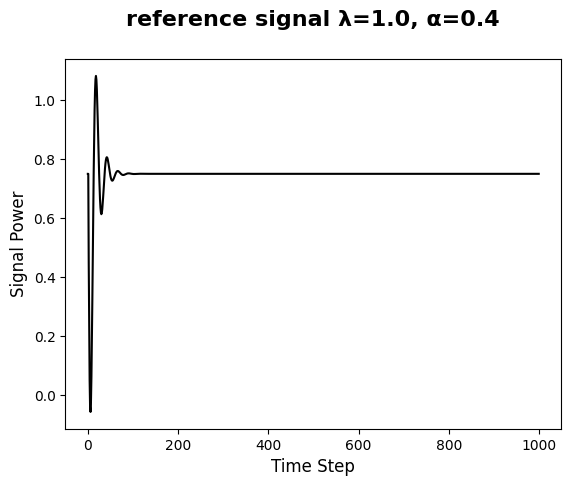

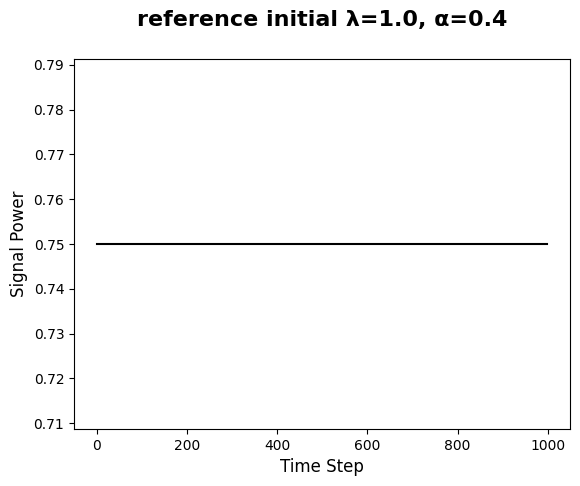

In [273]:
dcn = sys_04c.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-')
    plt.title(dcn[i] + f" λ={np.mean(l_val):.2}, α={a_val}", weight='bold', fontsize=16, pad=24)
    plt.ylabel("Signal Power", fontsize=12)
    plt.xlabel("Time Step", fontsize=12)
    plt.savefig(f"PICS/systems/system04_{dcn[i].replace("/","").replace(" ","-")}_l-{l_val}_a-{a_val}.png")
    plt.show()

In [283]:
def cont(l=1.0, a=0.2, seed=None, ts=100):
    if seed is None:
        np.random.seed(31415926)
    if ts == 100:
        tstag = ""
    else:
        tstag = "l"
    n = 1
    
    l_val = l
    a_val = a

    def sysinit():
        # AGENT
        # MAIN FEEDBACK CHAIN
        
        # get the state observation (behaviors of others)
        def sense(inputs):
            return inputs
        
        # contrast reference with observations (and potentially incorporate predictions from internal model)
        def compare(sensory_signal, reference):
            error = reference - sensory_signal
            return error
        
        # create a motor plan
        motor_transform = np.random.rand(n,n) 
        def effect(error, motor_state):
            lambda_val = l_val
            m_e = error @  motor_transform
            g_of_e_m = np.linalg.norm(error) * \
                (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
            next_motor_state = motor_state + lambda_val * g_of_e_m
            return next_motor_state
        
        # execute move
        def move(motor_signal):
            i = np.identity(motor_signal.shape[0])
            return motor_signal @ i
        
        # reference update via feedback
        def feedback(error, reference, reference_init):
            reference = reference - (error * a_val)
            # if ref_bounds is not None:
            #     reference[reference > ref_bounds[1]] = ref_bounds[1]
            #     reference[reference < ref_bounds[0]] = ref_bounds[0]
            return reference
        def feedback_false(error, reference, reference_init):
            return reference
        
        # SYSTEM INIT
        sys_04a = Agent(sense, compare, effect, move, feedback,
                        n, reference_initial=np.full((1,n), 0.75),
                        verbose=False)
        
         # -------------------------------------- #
        
        # PLANT
        
        T_scaler = 0.1
        transition_matrix = np.random.rand(n,n) * T_scaler 
        def plant_control(control_signal, state):
            output = control_signal @ transition_matrix + state
            return output
        
        # SYSTEM INIT
        sys_04b = System(np.zeros((2,n)),
                        ((None), (plant_control, [0,1])),
                        ["plant input", "plant output"],
                        output_channel_idx=1,
                        verbose=False)
        
         # -------------------------------------- #
        
        # TOTAL SYSTEM INIT
        sys_04c = System(np.random.rand(2,n),
                        ((sys_04b, [1]), (sys_04a, [0])),
                        ["agent input / plant behavior", "plant input / motor signal"],
                       verbose=False)
        sysout = sys_04c.go(ts)
        return (sysout, sys_04c.deep_channel_names())
    if seed is None:
        sysout, dcn = sysinit()
        comptag = ""
        fade = 2
    else:
        sysout_list = []
        for s in seed:
            np.random.seed(s)
            so, dcn = sysinit()
            sysout_list.append(so)
        sysout = np.concatenate(sysout_list, axis=2)
        comptag = "c"
        fade = len(seed)
        # raise NotImplementedError(":)")
    for i in range(sysout.shape[1]):
        plt.clf()
        plt.plot(sysout[:,i,:], 'k-', alpha=2/fade)
        plt.title(dcn[i] + f" λ={np.mean(l_val):.1}, α={a_val:.1f}", weight='bold', fontsize=16, pad=24)
        plt.ylabel("Signal Power", fontsize=12)
        plt.xlabel("Time Step", fontsize=12)
        plt.savefig(f"PICS/systems/system04{comptag}{tstag}_{dcn[i].replace("/","").replace(" ","-")}" + 
                    f"_l-{l_val:.1f}_a-{a_val:.1f}.png")
        # plt.show()

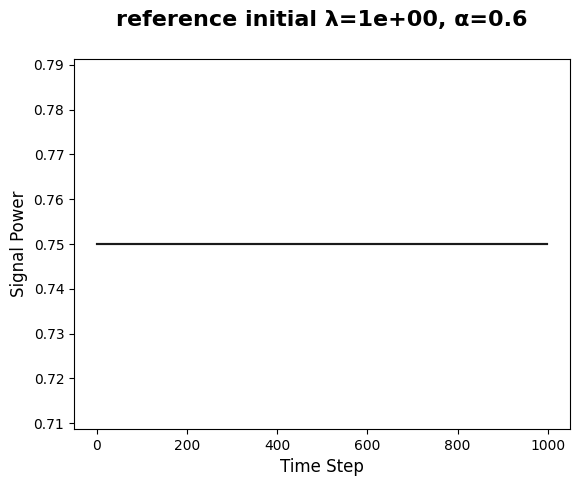

In [288]:
# for l in np.linspace(0,1,6):
#     for a in np.linspace(0,1,6):
#         print((l,a))
#         cont(l, a, seed=np.random.randint(1, 100000000, 20))
# cont(l=1, a=0.6, seed=np.random.randint(1, 100000000, 20), ts=1000)

## System_05 - (Conformist) Agent with Plant (n=10)

In [160]:
n = 20

l_val = 0.05 # + np.random.rand(n) * 0.01
a_val = 0.4

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n)
# motor_transform = np.eye(n,n)
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    # if ref_bounds is not None:
    #     reference[reference > ref_bounds[1]] = ref_bounds[1]
    #     reference[reference < ref_bounds[0]] = ref_bounds[0]
    return reference

# SYSTEM INIT
sys_05a = Agent(sense, compare, effect, move, feedback,
                n,
                # motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.9),
                verbose=True)

 # -------------------------------------- #

# PLANT

T_scaler = .1
transition_matrix = np.random.rand(n,n) * T_scaler 
def plant_control(control_signal, state):
    output = control_signal @ transition_matrix + state
    return output

# SYSTEM INIT
sys_05b = System(np.zeros((2,n)),
                ((None), (plant_control, [0,1])),
                ["plant input", "plant output"],
                output_channel_idx=1,
                verbose=True)

 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_05c = System(np.random.rand(2,n),
                ((sys_05b, [1]), (sys_05a, [0])),
                ["agent input", "plant input / agent behavior"],
               verbose=True)
sysout = sys_05c.go(400)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


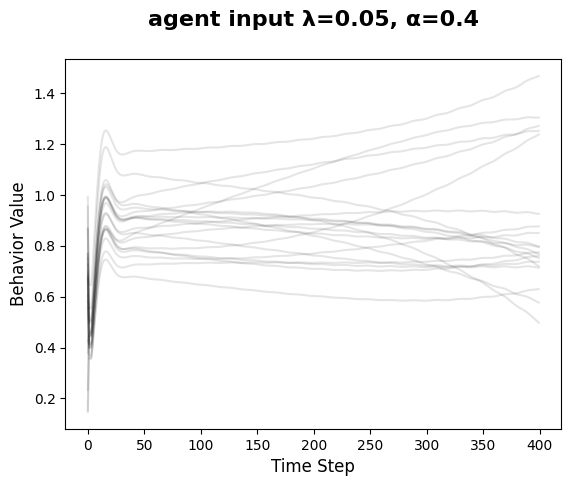

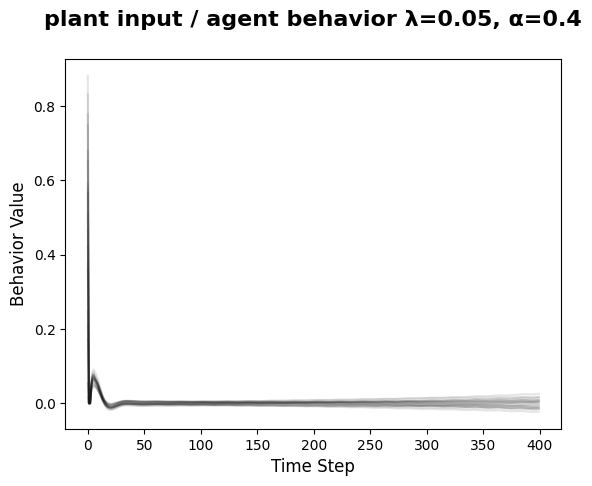

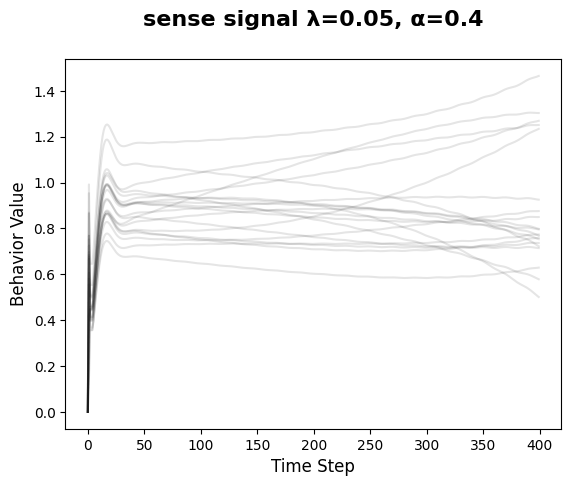

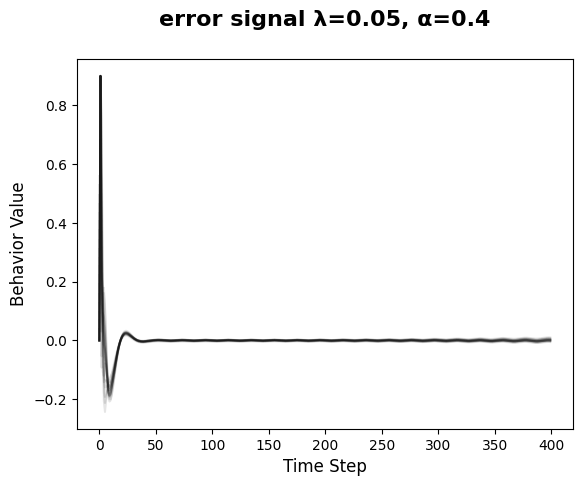

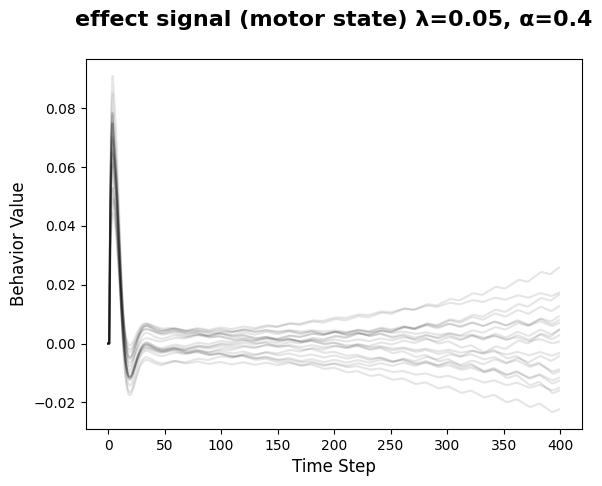

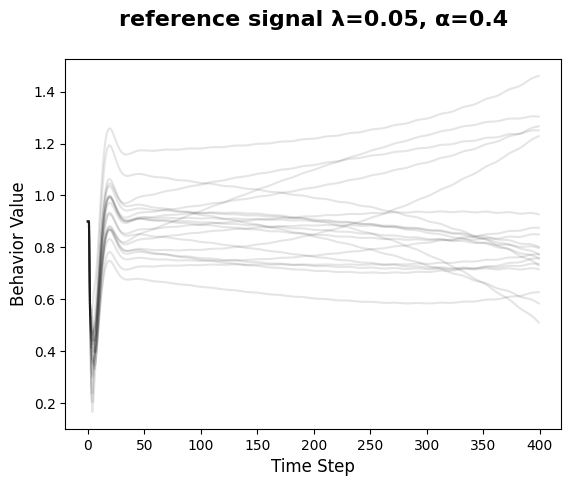

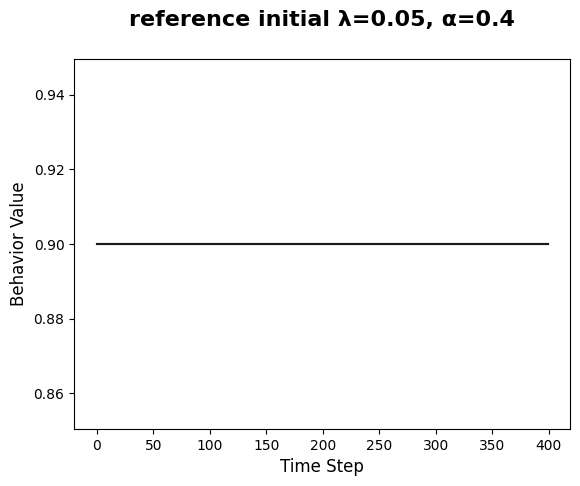

In [161]:
dcn = sys_05c.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i] + f" λ={np.mean(l_val):.2}, α={a_val}", weight='bold', fontsize=16, pad=24)
    plt.ylabel("Behavior Value", fontsize=12)
    plt.xlabel("Time Step", fontsize=12)
    plt.show()

In [313]:
def cont02(l=1.0, a=0.2, seed=None, ts=100):
    if seed is None:
        np.random.seed(31415926)
    if ts == 100:
        tstag = ""
    else:
        tstag = "l"
    n = 20
    
    l_val = l
    a_val = a

    def sysinit():
        # AGENT
        # MAIN FEEDBACK CHAIN
        
        # get the state observation (behaviors of others)
        def sense(inputs):
            return inputs
        
        # contrast reference with observations (and potentially incorporate predictions from internal model)
        def compare(sensory_signal, reference):
            error = reference - sensory_signal
            return error
        
        # create a motor plan
        motor_transform = np.random.rand(n,n) 
        def effect(error, motor_state):
            lambda_val = l_val
            m_e = error @  motor_transform
            g_of_e_m = np.linalg.norm(error) * \
                (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
            next_motor_state = motor_state + lambda_val * g_of_e_m
            return next_motor_state
        
        # execute move
        def move(motor_signal):
            i = np.identity(motor_signal.shape[0])
            return motor_signal @ i
        
        # reference update via feedback
        def feedback(error, reference, reference_init):
            reference = reference - (error * a_val)
            # if ref_bounds is not None:
            #     reference[reference > ref_bounds[1]] = ref_bounds[1]
            #     reference[reference < ref_bounds[0]] = ref_bounds[0]
            return reference
        def feedback_false(error, reference, reference_init):
            return reference
        
        # SYSTEM INIT
        sys_05a = Agent(sense, compare, effect, move, feedback,
                        n, reference_initial=np.full((1,n), 0.75),
                        verbose=False)
        
         # -------------------------------------- #
        
        # PLANT
        
        T_scaler = 0.1
        transition_matrix = np.random.rand(n,n) * T_scaler 
        def plant_control(control_signal, state):
            output = control_signal @ transition_matrix + state
            return output
        
        # SYSTEM INIT
        sys_05b = System(np.zeros((2,n)),
                        ((None), (plant_control, [0,1])),
                        ["plant input", "plant output"],
                        output_channel_idx=1,
                        verbose=False)
        
         # -------------------------------------- #
        
        # TOTAL SYSTEM INIT
        sys_05c = System(np.random.rand(2,n),
                        ((sys_05b, [1]), (sys_05a, [0])),
                        ["agent input / plant behavior", "plant input / motor signal"],
                       verbose=False)
        sysout = sys_05c.go(ts)
        return (sysout, sys_04c.deep_channel_names())
    if seed is None:
        sysout, dcn = sysinit()
        comptag = ""
        fade = n
    else:
        sysout_list = []
        for s in seed:
            np.random.seed(s)
            so, dcn = sysinit()
            sysout_list.append(np.mean(so, axis=2))
        sysout = np.stack(sysout_list, axis=2)
        comptag = "c"
        fade = len(seed)
        # raise NotImplementedError(":)")
    for i in range(sysout.shape[1]):
        plt.clf()
        plt.plot(sysout[:,i,:], 'k-', alpha=2/fade)
        plt.title(dcn[i] + f" λ={np.mean(l_val):.2}, α={a_val:.1f}", weight='bold', fontsize=16, pad=24)
        plt.ylabel("Signal Power", fontsize=12)
        plt.xlabel("Time Step", fontsize=12)
        plt.savefig(f"PICS/systems/system05{comptag}{tstag}_{dcn[i].replace("/","").replace(" ","-")}" + 
                    f"_l-{l_val:.2f}_a-{a_val:.1f}.png")
        # plt.show()

(np.float64(0.0), np.float64(0.0))
(np.float64(0.0), np.float64(0.2))
(np.float64(0.0), np.float64(0.4))
(np.float64(0.0), np.float64(0.6000000000000001))
(np.float64(0.0), np.float64(0.8))
(np.float64(0.0), np.float64(1.0))
(np.float64(0.05), np.float64(0.0))
(np.float64(0.05), np.float64(0.2))
(np.float64(0.05), np.float64(0.4))
(np.float64(0.05), np.float64(0.6000000000000001))
(np.float64(0.05), np.float64(0.8))
(np.float64(0.05), np.float64(1.0))
(np.float64(0.1), np.float64(0.0))
(np.float64(0.1), np.float64(0.2))
(np.float64(0.1), np.float64(0.4))
(np.float64(0.1), np.float64(0.6000000000000001))
(np.float64(0.1), np.float64(0.8))
(np.float64(0.1), np.float64(1.0))
(np.float64(0.15000000000000002), np.float64(0.0))
(np.float64(0.15000000000000002), np.float64(0.2))
(np.float64(0.15000000000000002), np.float64(0.4))
(np.float64(0.15000000000000002), np.float64(0.6000000000000001))
(np.float64(0.15000000000000002), np.float64(0.8))
(np.float64(0.15000000000000002), np.float64(1.0)

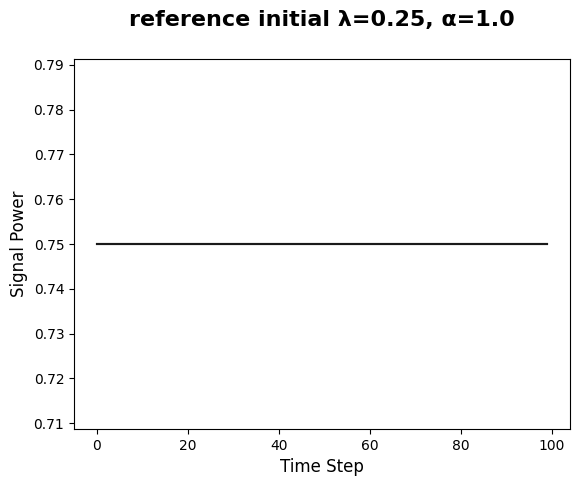

In [323]:
for l in np.linspace(0,0.25,6):
    for a in np.linspace(0,1,6):
        print((l,a))
        # cont02(l, a)
        # cont02(l, a, seed=np.random.randint(1, 100000000, 20))
# cont02(l=0.05, a=0.99, ts=1000)
# cont02(l=1, a=0.6, seed=np.random.randint(1, 100000000, 20), ts=1000)

## System_06 - Dual Agent (n=10)

In [58]:
n = 10

l_val = 0.2

a_val = 0.8
a_val_pw = 0.8

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n)
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    return reference
# does not adjust reference
def feedback_false(error, reference, reference_init):
    return reference
# peacewise feedback
def feedback_piecewise(error, reference, reference_init):
    mu = 0.000000010
    sqr_error = np.square(error)
    msq_error  = np.mean(sqr_error)
    # print(msq_error)
    if msq_error < mu:
        return reference_init
    else:
        return reference - (error * a_val_pw)

# SYSTEM INIT
sys_06a = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), -0.5),
                name="Agent_1 (conformist)",
                verbose=True)

# ------ #

# SYSTEM INIT
sys_06b = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (conformist)",
                verbose=True)

# SYSTEM INIT
sys_06c = Agent(sense, compare, effect, move, feedback_false,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (stubborn)",
                verbose=True)

# SYSTEM INIT
sys_06d = Agent(sense, compare, effect, move, feedback_piecewise,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (hybrid)",
                verbose=True)

 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_06_total = System(np.random.rand(2,n),
                ((sys_06d, [1]), (sys_06a, [0])),
                ["Agent_1 input", "Agent_2 input"],
               verbose=True)

sysout = sys_06_total.go(5000)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


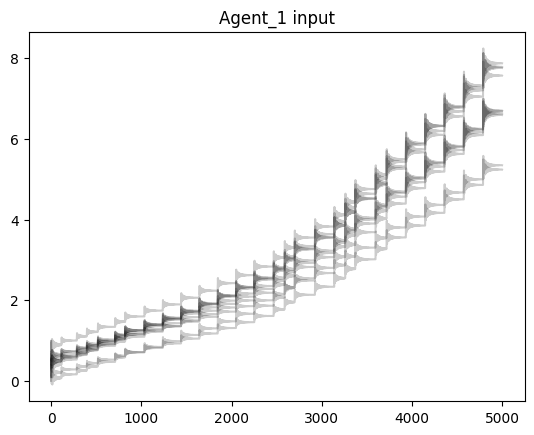

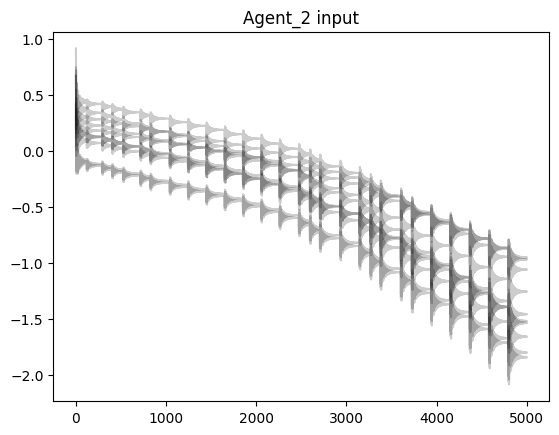

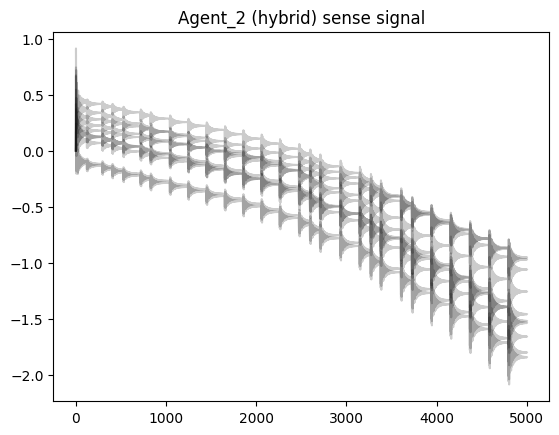

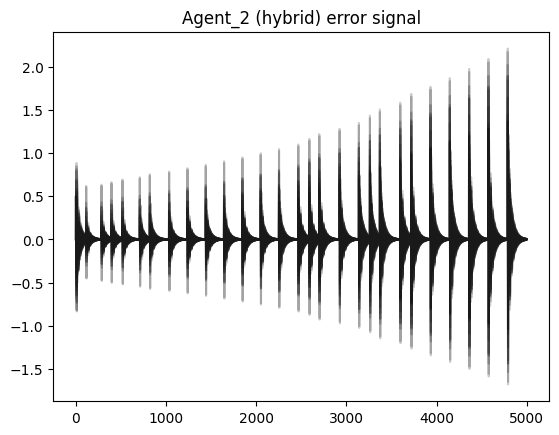

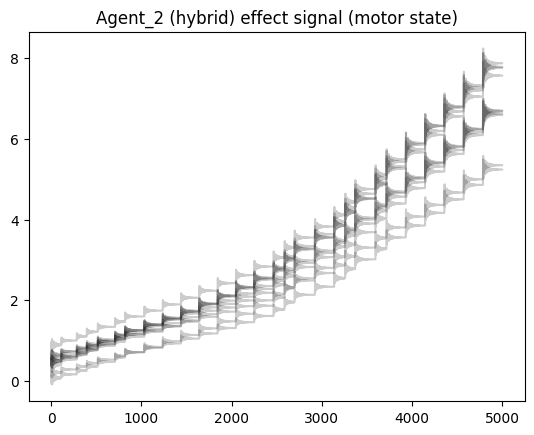

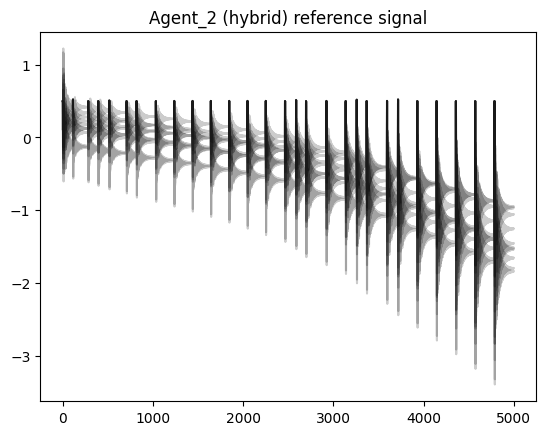

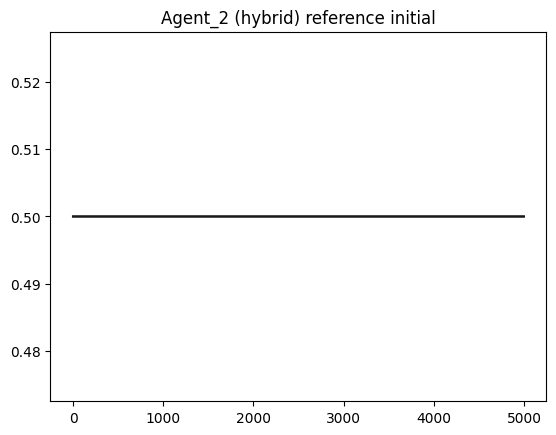

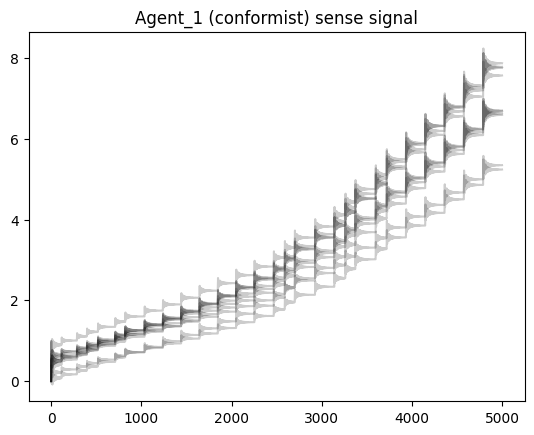

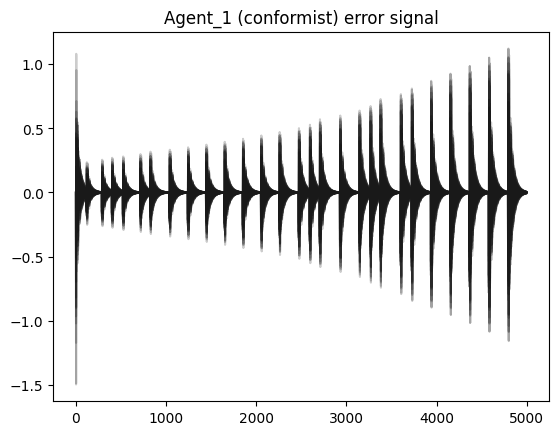

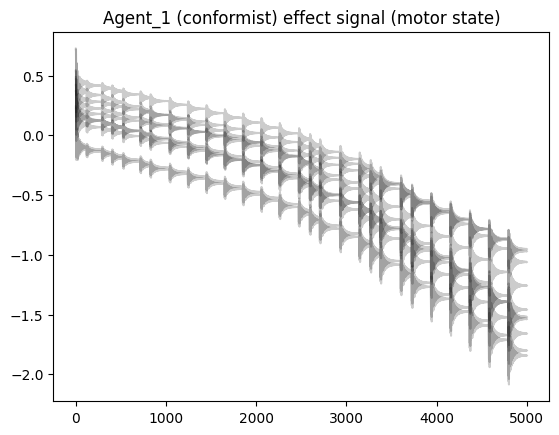

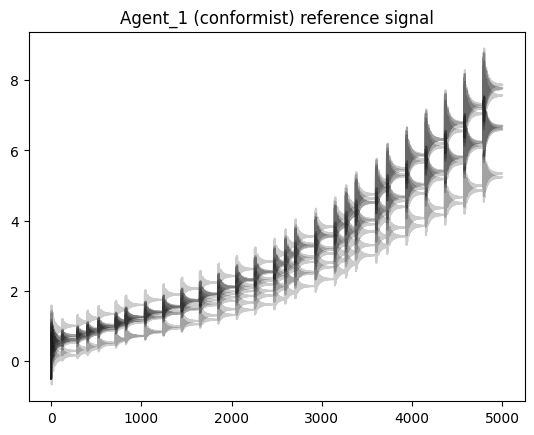

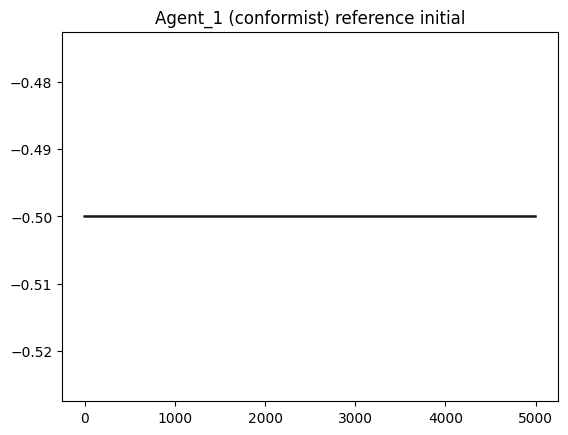

In [61]:
dcn = sys_06_total.deep_channel_names()
def plot_sysout(i):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i])
    plt.show()

for i in range(sysout.shape[1]):
    plot_sysout(i)


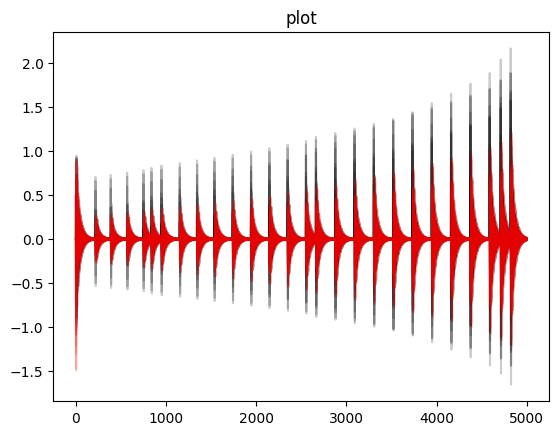

In [49]:
plt.plot(sysout[:,3,:], 'k-', alpha=2/n)
plt.plot(sysout[:,8,:], 'r-', alpha=2/n)
# plt.ylim(-0.1,0.1)
plt.title("plot")
plt.show()

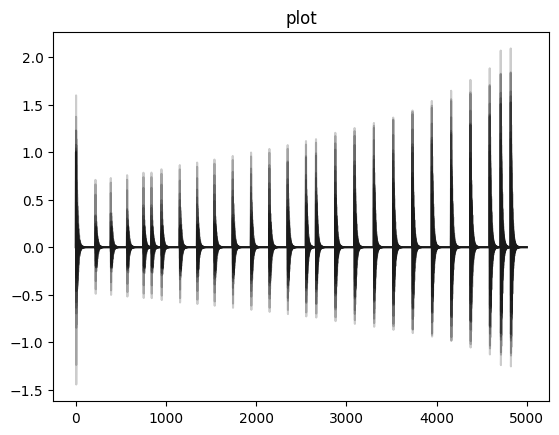

In [50]:
plt.plot(sysout[:,3,:] - sysout[:,8,:], 'k-', alpha=2/n)
# plt.ylim(-0.1,0.1)
plt.title("plot")
plt.show()

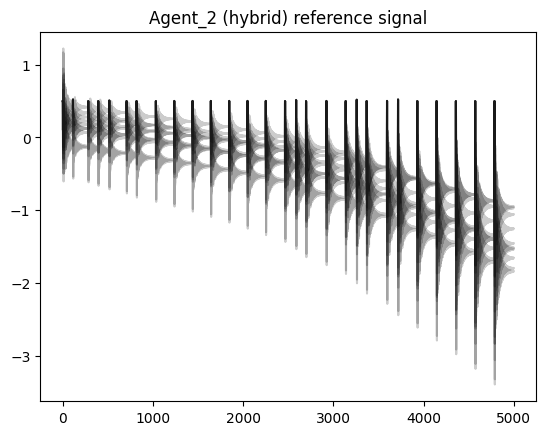

In [62]:
plot_sysout(5)

In [67]:
sd.play(sysout[:,5,1], 1000)

In [ ]:
dcn = sys_06_total.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i])
    plt.show()

In [39]:
def cont03(l=0.01, a=0.1, apw=0.1, seed=None, ts=100, mode="dual"):
    if seed is None:
        np.random.seed(31415926)
    if np.log10(ts) <= 2:
        tstag = ""
    else:
        tstag = int(np.log10(ts) - 2) * "l"
    n = 20
    
    l_val = l
    
    a_val = a
    a_val_pw = apw
    
    def sysinit():
        # AGENT
        # MAIN FEEDBACK CHAIN
        
        # get the state observation (behaviors of others)
        def sense(inputs):
            return inputs
        
        # contrast reference with observations (and potentially incorporate predictions from internal model)
        def compare(sensory_signal, reference):
            error = reference - sensory_signal
            return error
        
        # create a motor plan
        motor_transform = np.random.rand(n,n)
        def effect(error, motor_state):
            lambda_val = l_val
            m_e = error @  motor_transform
            g_of_e_m = np.linalg.norm(error) * \
                (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
            next_motor_state = motor_state + lambda_val * g_of_e_m
            return next_motor_state
        
        # execute move
        def move(motor_signal):
            i = np.identity(motor_signal.shape[0])
            return motor_signal @ i
        
        # reference update via feedback
        def feedback(error, reference, reference_init):
            reference = reference - (error * a_val)
            return reference
        # does not adjust reference
        def feedback_false(error, reference, reference_init):
            return reference
        # peacewise feedback
        def feedback_piecewise(error, reference, reference_init):
            mu = 0.0010
            sqr_error = np.square(error)
            msq_error  = np.mean(sqr_error)
            # print(msq_error)
            if msq_error < mu:
                return reference_init
            else:
                return reference - (error * a_val_pw)
        
        # SYSTEM INIT
        sys_06a = Agent(sense, compare, effect, move, feedback,
                        n, 
                        motor_prior=np.random.rand(1,n),
                        reference_initial=np.full((1,n), -0.5),
                        name="Agent_1 (conformist)",
                        verbose=False)
        
        # ------ #

        if mode == "conformist":
            fbfn = feedback
        elif mode == "stubborn":
            fbfn = feedback_false
        elif mode == "hybrid":
            fbfn = feedback_piecewise
        else:
            raise ValueError("Not a valid mode")
        
        # SYSTEM INIT
        sys_06b = Agent(sense, compare, effect, move, fbfn,
                        n, 
                        motor_prior=np.random.rand(1,n),
                        reference_initial=np.full((1,n), 0.5),
                        name=f"Agent_2 ({mode})",
                        verbose=False)
        
         # -------------------------------------- #
        
        # TOTAL SYSTEM INIT
        sys_06_total = System(np.random.rand(2,n),
                        ((sys_06b, [1]), (sys_06a, [0])),
                        ["Agent_1 input", "Agent_2 input"],
                       verbose=False)
        
        sysout = sys_06_total.go(ts)
        dcn = sys_06_total.deep_channel_names()
        return (sysout, sys_06_total.deep_channel_names())
    if seed is None:
        sysout, dcn = sysinit()
        comptag = ""
        fade = n
    else:
        sysout_list = []
        for s in seed:
            np.random.seed(s)
            so, dcn = sysinit()
            sysout_list.append(np.mean(so, axis=2))
        sysout = np.stack(sysout_list, axis=2)
        comptag = "c"
        fade = len(seed)
        # raise NotImplementedError(":)")
    # print(dcn)
    for i in range(sysout.shape[1]):
        plt.clf()
        plt.plot(sysout[:,i,:], 'k-', alpha=2/fade)
        plt.title(dcn[i] + f" λ={np.mean(l_val):.2}, α={a_val:.1f}", weight='bold', fontsize=12, pad=24)
        plt.ylabel("Signal Power", fontsize=12)
        plt.xlabel("Time Step", fontsize=12)
        plt.savefig(f"PICS/systems/system06{comptag}{tstag}_mode-{mode[0]}_{dcn[i].replace("/","").replace(" ","-")}" + 
                    f"_l-{l_val:.2f}_a-{a_val:.1f}.png")
        # plt.show()

(np.float64(0.0), np.float64(0.0))
(np.float64(0.0), np.float64(0.2))
(np.float64(0.0), np.float64(0.4))
(np.float64(0.0), np.float64(0.6000000000000001))
(np.float64(0.0), np.float64(0.8))
(np.float64(0.0), np.float64(1.0))
(np.float64(0.05), np.float64(0.0))
(np.float64(0.05), np.float64(0.2))
(np.float64(0.05), np.float64(0.4))
(np.float64(0.05), np.float64(0.6000000000000001))
(np.float64(0.05), np.float64(0.8))
(np.float64(0.05), np.float64(1.0))
(np.float64(0.1), np.float64(0.0))
(np.float64(0.1), np.float64(0.2))
(np.float64(0.1), np.float64(0.4))
(np.float64(0.1), np.float64(0.6000000000000001))
(np.float64(0.1), np.float64(0.8))
(np.float64(0.1), np.float64(1.0))
(np.float64(0.15000000000000002), np.float64(0.0))
(np.float64(0.15000000000000002), np.float64(0.2))
(np.float64(0.15000000000000002), np.float64(0.4))
(np.float64(0.15000000000000002), np.float64(0.6000000000000001))
(np.float64(0.15000000000000002), np.float64(0.8))
(np.float64(0.15000000000000002), np.float64(1.0)

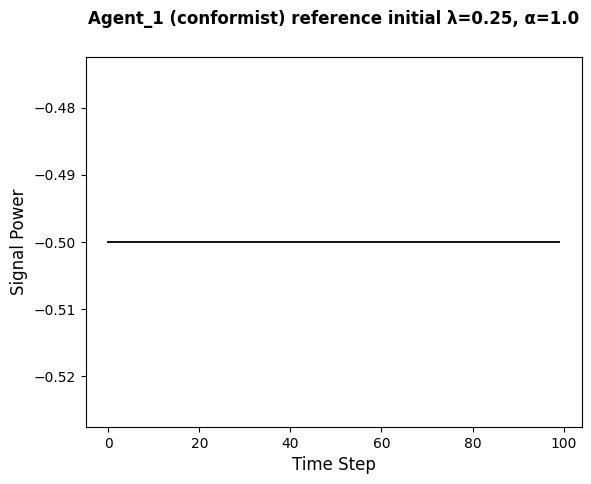

In [42]:
for l in np.linspace(0,0.25,6):
    for a in np.linspace(0,1,6):
        print((l,a))
        # cont03(l, a, a, mode="hybrid")
        # cont03(l, a, a, mode="hybrid", seed=np.random.randint(1, 100000000, 50))
# cont03(l=0.03, a=0.8, apw=0.8, mode="hybrid", ts=10000)
# cont02(l=1, a=0.6, seed=np.random.randint(1, 100000000, 20), ts=1000)

## System_07 - Dual Agent + Extra (n=10)

In [73]:
n = 10

l_val = 0.01
l_val2 = 0.01

a_val = 0.2
a_val2 = 0.2

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n)
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

motor_transform2 = np.random.rand(n,n)
def effect2(error, motor_state):
    lambda_val = l_val2
    m_e = error @  motor_transform2
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    return reference
def feedback_2nd_order(error, reference, reference_init):
    reference = reference - (error * a_val2)
    return reference    
# does not adjust reference
def feedback_false(error, reference, reference_init):
    return reference
# peacewise feedback
def feedback_piecewise(error, reference, reference_init):
    mu = 0.0010
    sqr_error = np.square(error)
    msq_error  = np.mean(sqr_error)
    # print(msq_error)
    if msq_error < mu:
        return reference_init
    else:
        return reference - (error * a_val_pw)

# SYSTEM INIT
sys_07a = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), -0.5),
                name="Agent_1 (conformist)",
                verbose=True)

# ------ #

# SYSTEM INIT
sys_07b = Agent(sense, compare, effect2, move, feedback_2nd_order,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (inner)",
                verbose=True)

sys_07bw = System(np.zeros((4,n)),
                (None, None, None, (sys_07b, [0])),
                ["Agent_2_i input", "_", "_", "Agent_2_i ouput"],
                output_channel_idx=3,
                verbose=True)


# SYSTEM INIT
sys_07c = Agent(sense, compare, effect, move, sys_07bw,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (outer)",
                verbose=True)


 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_07_total = System(np.random.rand(2,n),
                ((sys_07c, [1]), (sys_07a, [0])),
                ["Agent_1 input", "Agent_2 input"],
               verbose=True)

sysout = sys_07_total.go(100)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0, 1, 2]
input chan idxs: [0]
input chan idxs: []


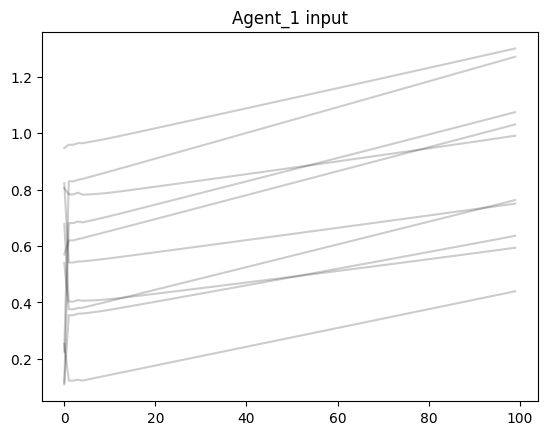

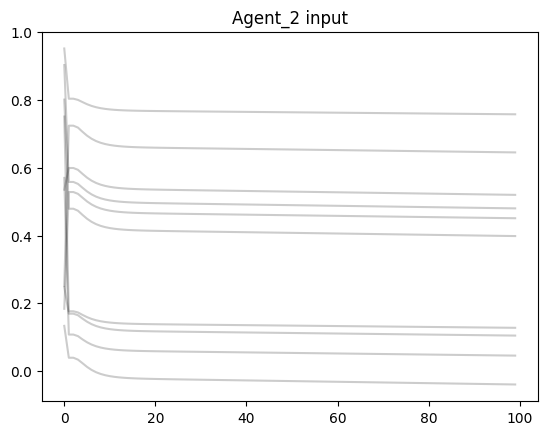

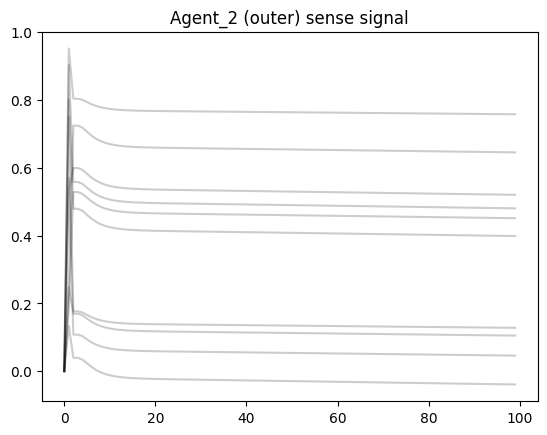

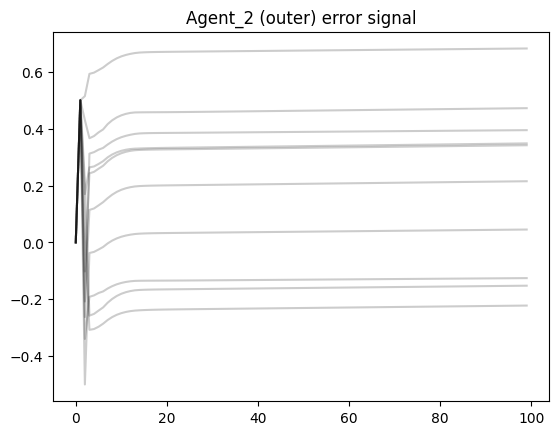

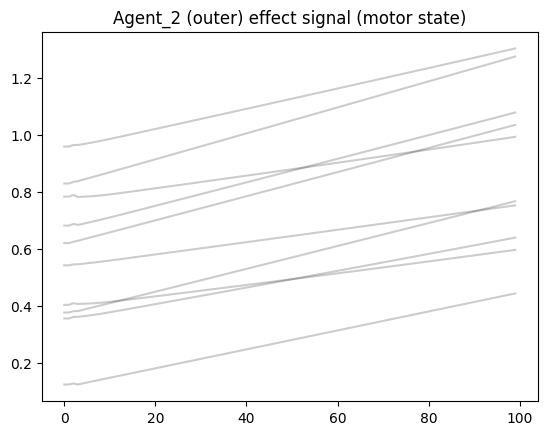

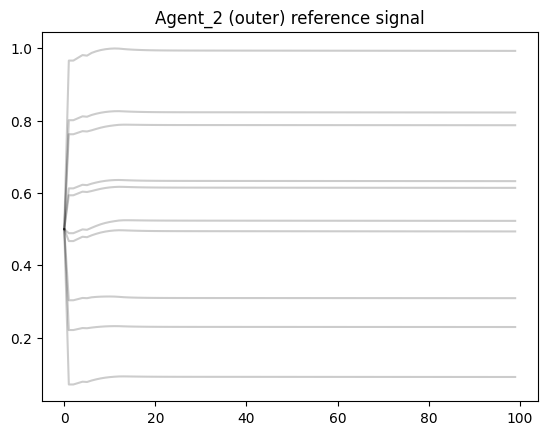

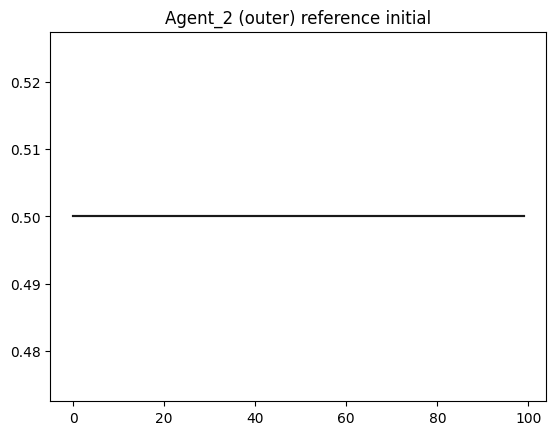

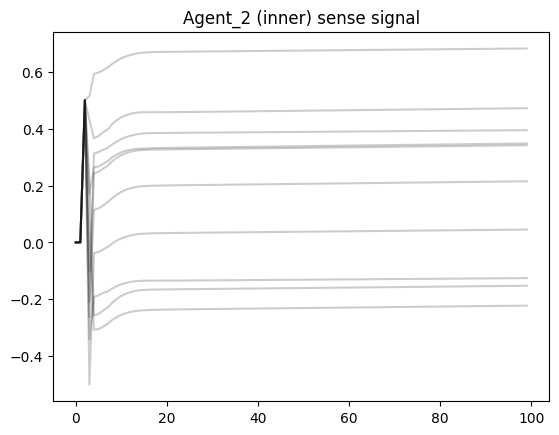

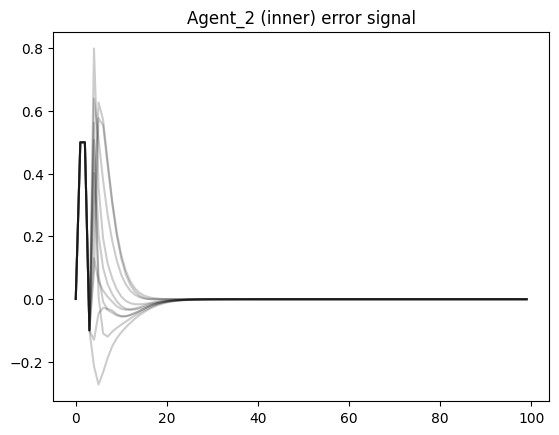

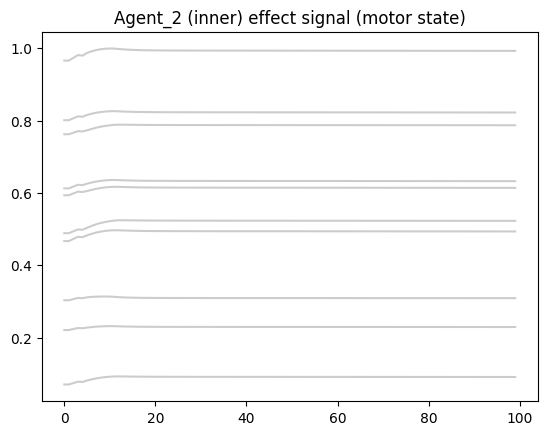

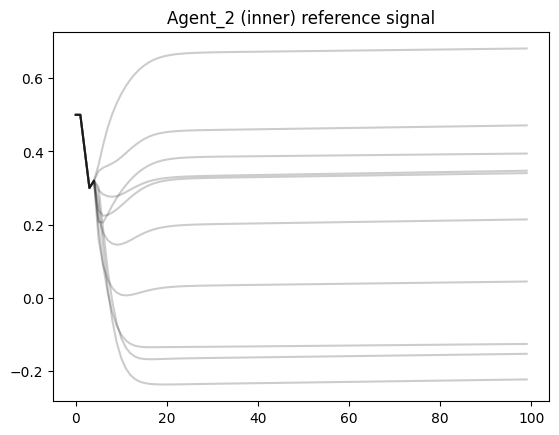

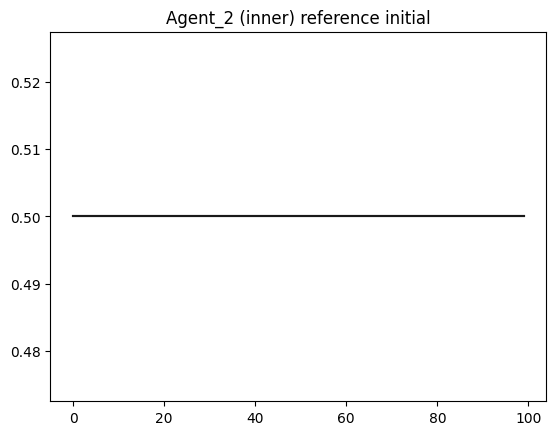

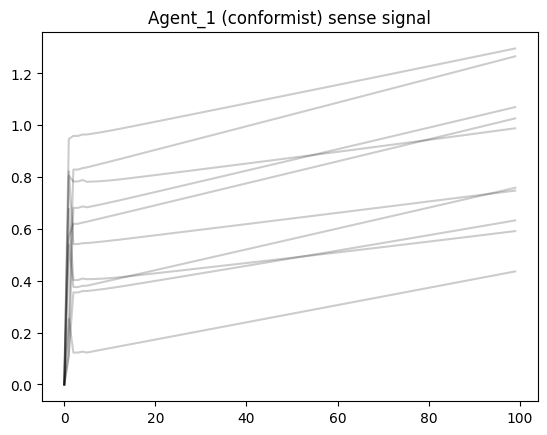

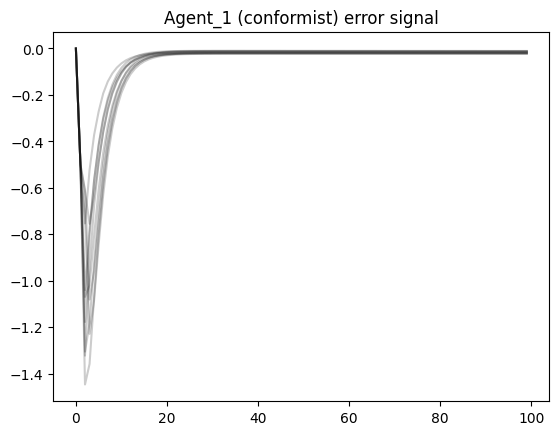

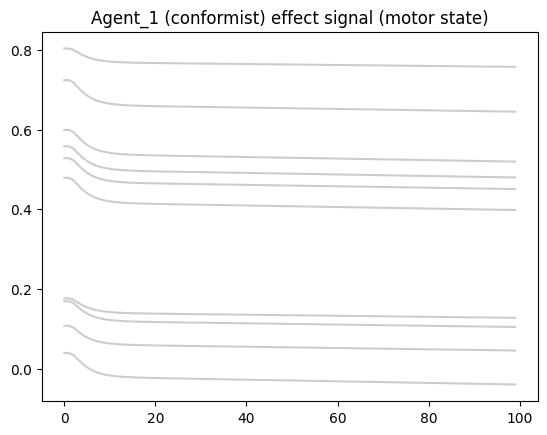

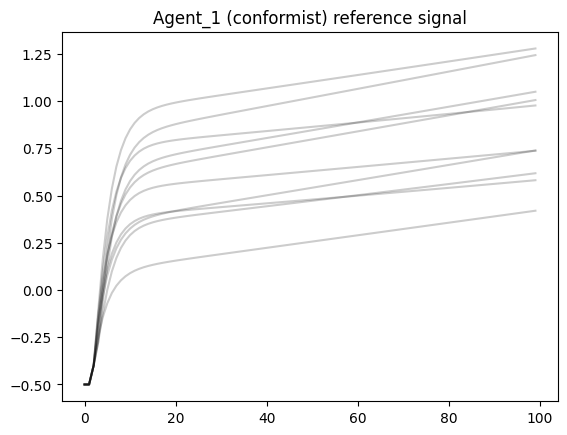

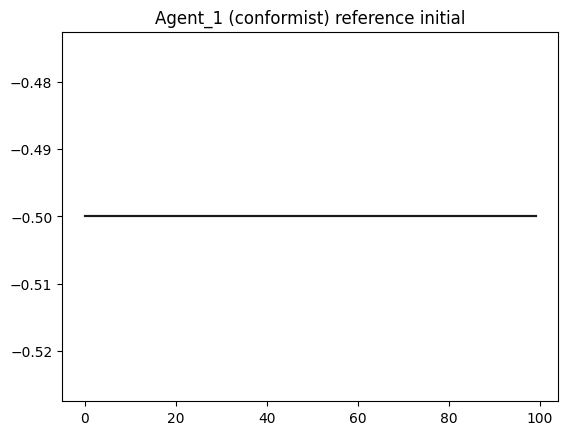

In [74]:
dcn = sys_07_total.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i])
    plt.show()

## System_08 - Demux

In [3]:
sys_08a = System(np.array([[0.0],[0.0]]),
                 (None, (identity, [0])),
                 output_channel_idx=1,
                 name="bottom",
                 verbose=True)

sys_08b = System(np.array([[0.0],[0.0]]),
                 ((None), (identity, [0])),
                 output_channel_idx=1,
                 name="top",
                 verbose=True)

sys_08c = System(np.array([[0.0],[0.0],[0.0],[0.0]]),
                ((None), (None), (identity, [0]), (identity, [1])),
                output_channel_idx=[2,3],
                name="middle",
                verbose=True)

sys_08d = System(np.array([[1.0],[2.0],[3.0],[4.0]]),
                 ((sys_08a, [3]), (sys_08b, [2]), (sys_08c, [0,1]), 2),
                 channel_names=["bottom out", "top out", "mid out 1", "mid out 2"],
                 verbose=True)

sysout = sys_08d.go(10)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0, 1]
input chan idxs: []


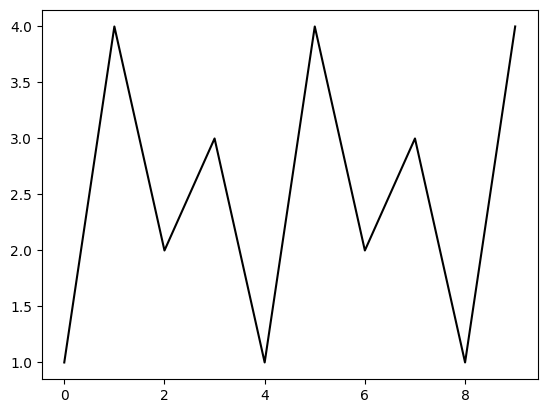

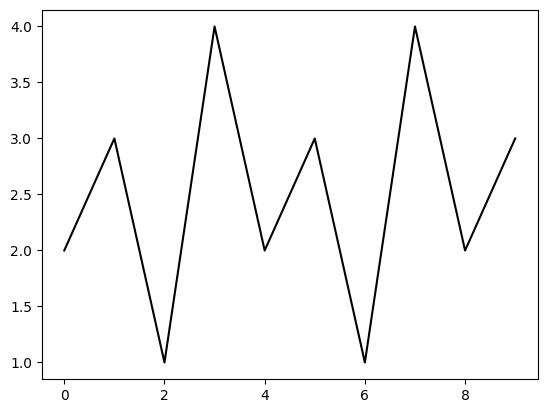

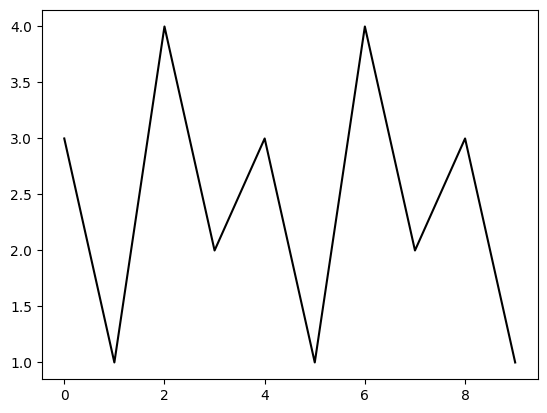

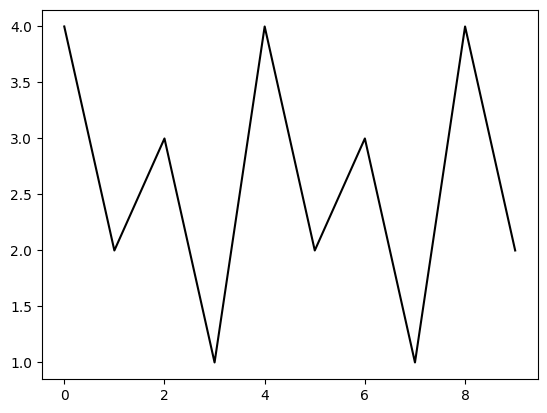

In [4]:
dcn = sys_08d.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(np.max(sysout[:,i,:], axis=1), 'k-')
    plt.show()

## System_09 - Dual Agent with non-lin (n=10)

In [135]:
n = 10

l_val = 0.2

a_val = 0.8
a_val_pw = 0.8

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# # create a motor plan
# motor_transform = np.random.rand(n,n)
# def effect(error, motor_state):
#     print(motor_state)
#     lambda_val = l_val
#     m_e = error @  motor_transform
#     g_of_e_m = np.linalg.norm(error) * \
#         (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
#     next_motor_state = motor_state + lambda_val * g_of_e_m
#     return next_motor_state

# create a motor plan
motor_transform = np.random.rand(n,n)
err_exp = np.round(np.random.rand(n)*3)
# err_exp = np.ones(n)
# err_int = np.random.rand(n)*20-10
err_int = np.zeros(n)
def effect(error, motor_state):
    lambda_val = l_val
    err_mod = np.power((error+err_int), err_exp)
    m_e = err_mod @  motor_transform
    g_of_e_m = np.linalg.norm(err_mod) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    return reference
# does not adjust reference
def feedback_false(error, reference, reference_init):
    return reference
# peacewise feedback
def feedback_piecewise(error, reference, reference_init):
    mu = 0.0000010
    sqr_error = np.square(error)
    msq_error  = np.mean(sqr_error)
    # print(msq_error)
    if msq_error < mu:
        return reference_init
    else:
        return reference - (error * a_val_pw)

# SYSTEM INIT
sys_09a = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), -0.5),
                name="Agent_1 (conformist)",
                verbose=True)

# ------ #

# SYSTEM INIT
sys_09b = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (conformist)",
                verbose=True)

# SYSTEM INIT
sys_09c = Agent(sense, compare, effect, move, feedback_false,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (stubborn)",
                verbose=True)

# SYSTEM INIT
sys_09d = Agent(sense, compare, effect, move, feedback_piecewise,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (hybrid)",
                verbose=True)

 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_09_total = System(np.random.rand(2,n),
                ((sys_09d, [1]), (sys_09a, [0])),
                ["Agent_1 input", "Agent_2 input"],
               verbose=True)

sysout = sys_09_total.go(200)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


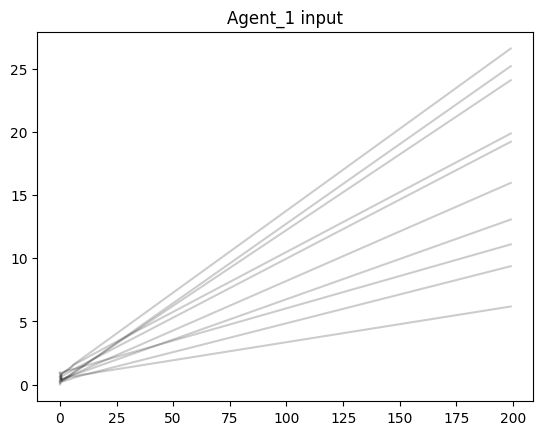

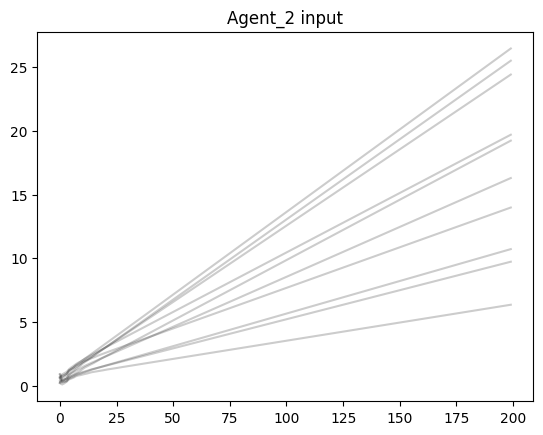

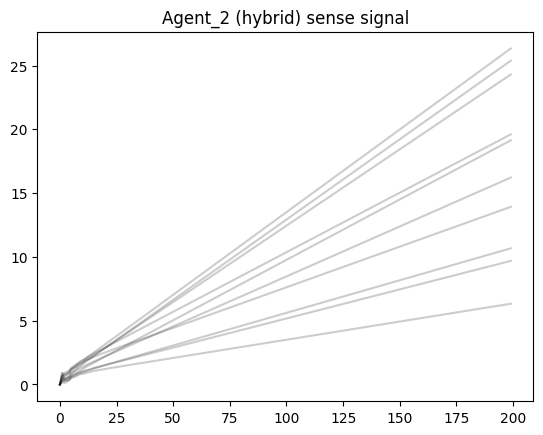

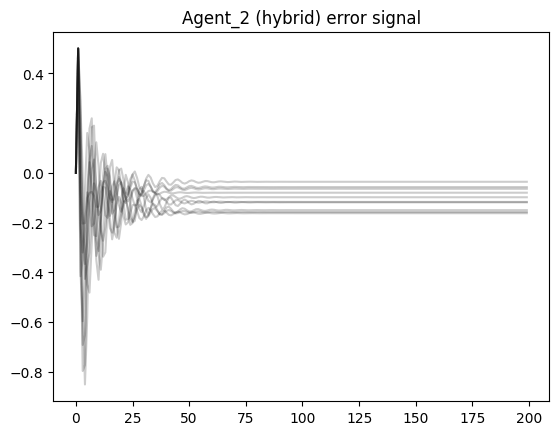

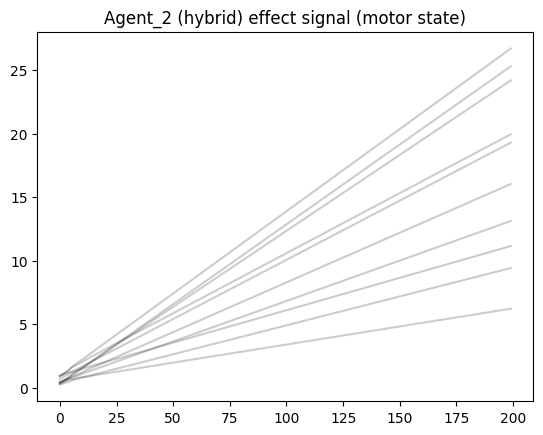

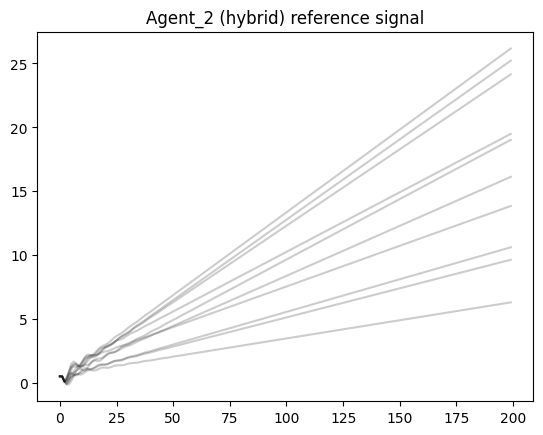

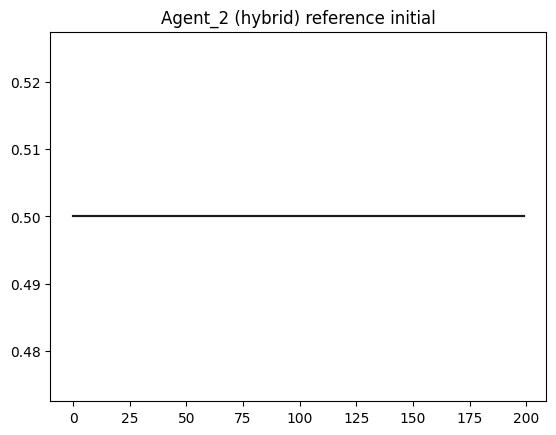

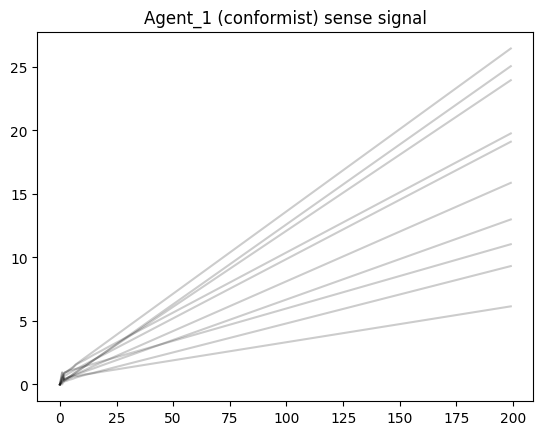

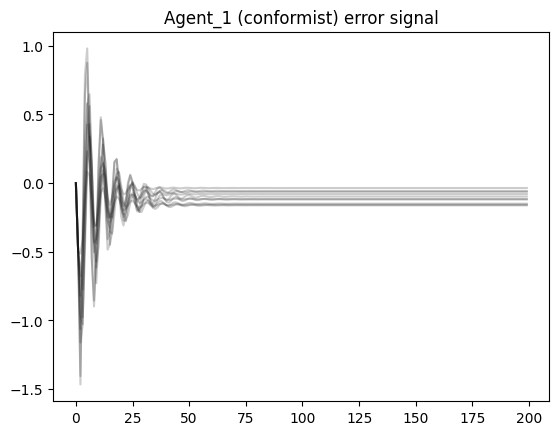

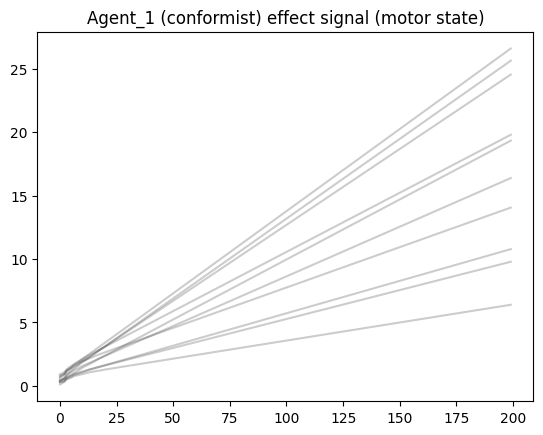

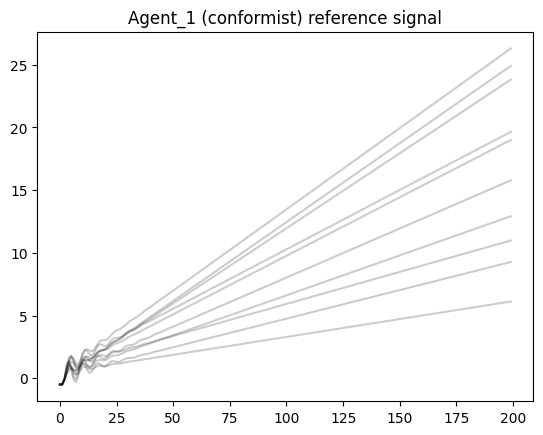

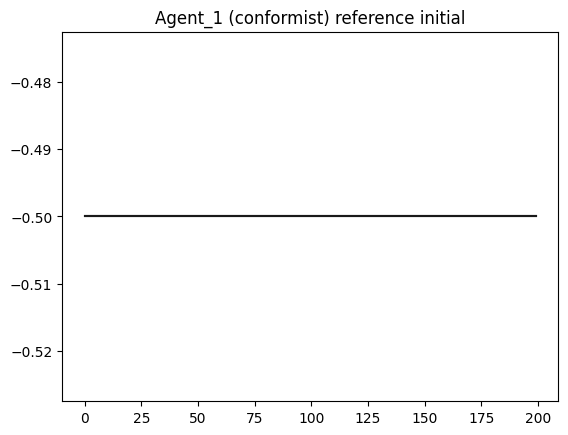

In [136]:
dcn = sys_09_total.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i])
    plt.show()

## System_10 - Dual Agent with non-lin (n=10)

In [4]:
class RELUagent(System):
    """A social agent control system

    """
    def __init__(
            self,
            sensor,
            comparator,
            effector,
            motor,
            feedback,
            signal_len,
            motor_prior=None,
            reference_initial=None,
            channel_names=None,
            **kwargs
            ):
        """Creates an RELU agent

        Parmeters
        ---------
        sensor : (numpy.ndarray) -> numpy.ndarray
            Sensory compression function.
        comparator : (numpy.ndarray, numpy.ndarray) -> numpy.ndarray
            Comparator function. 
        effector : (numpy.ndarray, numpy.ndarray) -> numpy.ndarray
            Effector function.
        motor : (numpy.ndarray) -> numpy.ndarray
            Motor decompression function.
        feedback : (ndarray, ndarray, ndarray) -> ndarray
            Reference update function.
        signal_len : int
            Max length of a signal.
        motor_prior : 1D numpy.ndarray, optional
            The inital state of the effector signal.
        reference_initial : 1D numpy.ndarray, optional
            The inital state of the reference signal.
        channel_names : list of str, optional
            The names for each of the seven channels. Otherwise auto-assigned.

        """
        self._signal_len = signal_len
        n = signal_len

        if motor_prior is None:
            motor_prior = np.zeros((1,n))
        if reference_initial is None:
            reference_initial = np.zeros((1,n))
        state_space = np.concatenate(
            [np.zeros((1,n)),    # 0 input
             np.zeros((1,n)),    # 1 sense signal
             np.full((1,n),0.001),    # 2 error signal
             motor_prior,        # 3 effect signal (motor state)
             np.zeros((1,n)),    # 4 motor signal / output
             reference_initial,  # 5 reference signal
             reference_initial,  # 6 reference initial
             np.ones((1,n))])   # 7 relu update

        transition_functions = [
            None,                # 0 input
            (sensor, [0]),       # 1 sense signal
            (comparator, [1,5]), # 2 error signal
            (effector, [2,3,7]),   # 3 effect signal
            (motor, [3]),        # 4 motor signal / output
            (feedback, [2,5,6,7]), # 5 reference signal
            (lambda x: x, [6]),  # 6 reference initial
            5]                   # 7 relu update

        if channel_names is None:
            channel_names = ["input",
                "sense signal",
                "error signal",
                "effect signal (motor state)",
                "motor signal / output",
                "reference signal",
                "reference initial",
                "relu update"]
        super().__init__(state_space,
            transition_functions,
            channel_names=channel_names,
            output_channel_idx=4,
            **kwargs)

In [5]:
np.random.seed(42069)
n = 5

l_val = 0.2

a_val = 0.7
a_val_pw = 0.7

# relu_a_val = 1.0
relu_a_val = 1

def dual_leaky_relu(x, alpha=np.full(n,relu_a_val)):
    neg_alpha_mask = alpha < 0
    out = np.maximum(alpha * x, x)
    out[neg_alpha_mask] = np.minimum(-1 * alpha * x, x)[neg_alpha_mask] 
    return out

# --------------------- #

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n) * 2 - 1
# motor_transform = np.arange(0,1,1/25).reshape(5,5).T
# motor_transform = np.full((5,5),0.5)
def effect(error, motor_state, alpha=np.full(n,relu_a_val)):
    # error = dual_leaky_relu(error, alpha)
    lambda_val = l_val
    m_e = error @  (motor_transform * alpha)
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    return reference
# peacewise feedback
def feedback_piecewise(error, reference, reference_init, relu_update):
    mu = 0.000000010
    sqr_error = np.square(error)
    msq_error  = np.mean(sqr_error)
    # print(msq_error)
    if msq_error < mu:
        ref_diff = reference - reference_init
        relu_alph = ref_diff
        # print(msq_error)
        return (reference_init, relu_alph * -1)
    else:
        return (reference - (error * a_val_pw), relu_update)

# SYSTEM INIT
sys_10a = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), -0.5),
                name="Agent_1 (conformist)",
                verbose=True)

# ------ #

# SYSTEM INIT
sys_10b = RELUagent(sense, compare, effect, move, feedback_piecewise,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (hybrid)",
                verbose=True)

 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_10_total = System(np.random.rand(2,n),
                ((sys_10b, [1]), (sys_10a, [0])),
                ["Agent_1 input", "Agent_2 input"],
               verbose=True)

sysout = sys_10_total.go(800)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


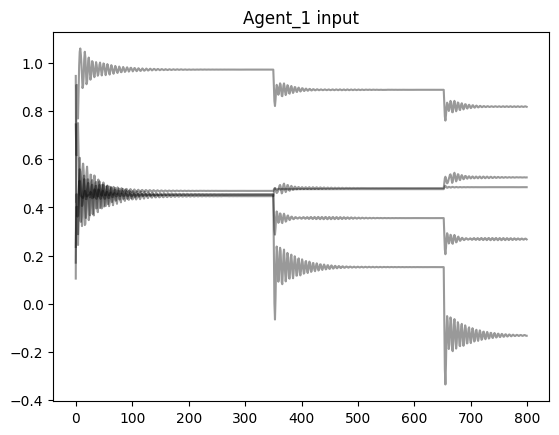

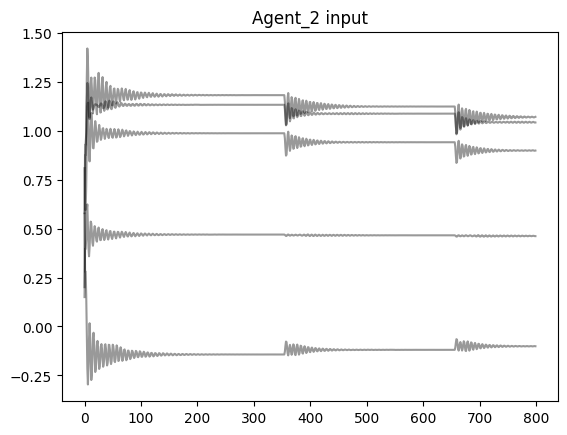

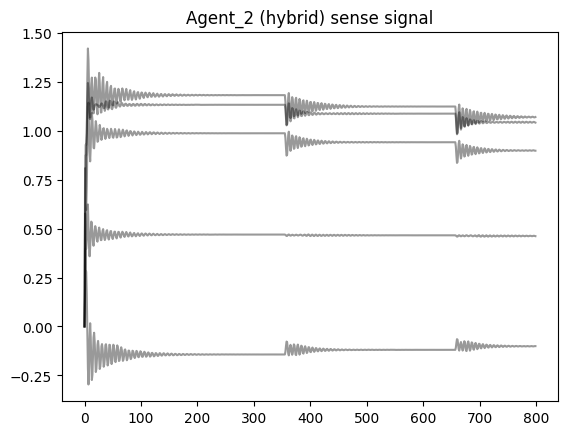

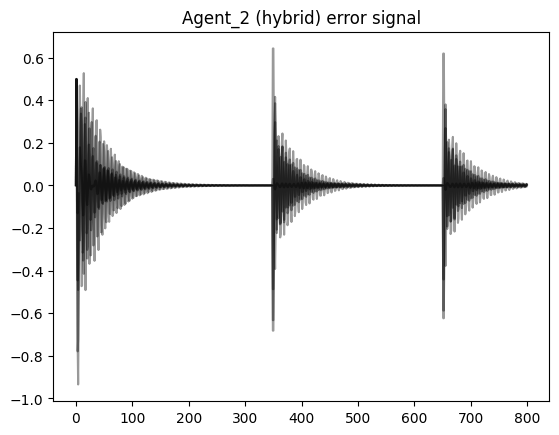

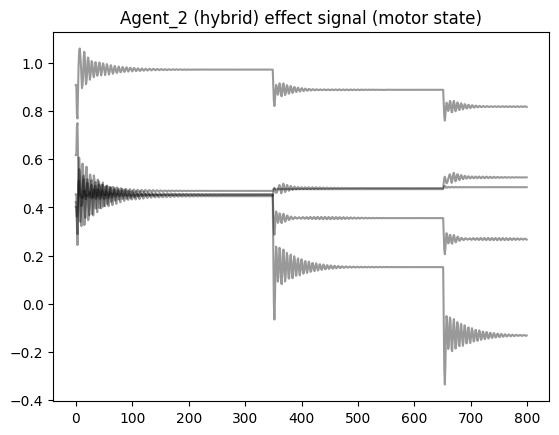

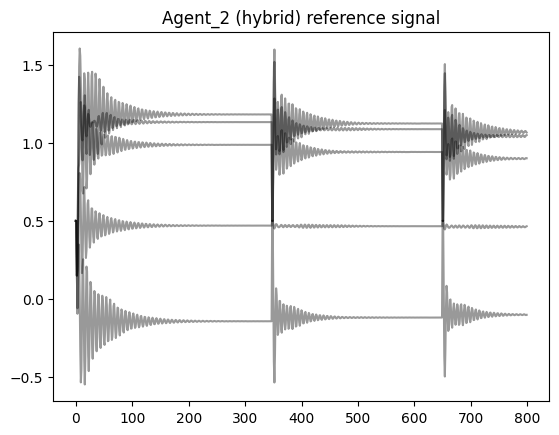

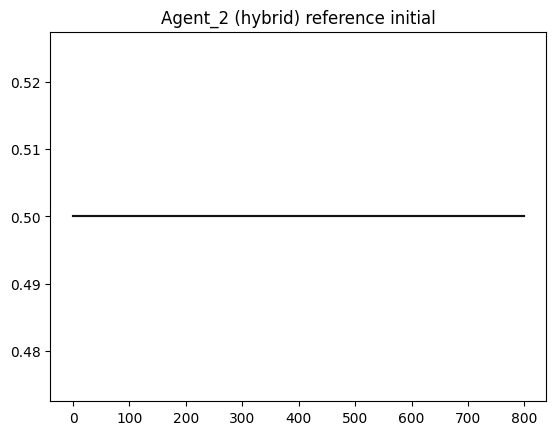

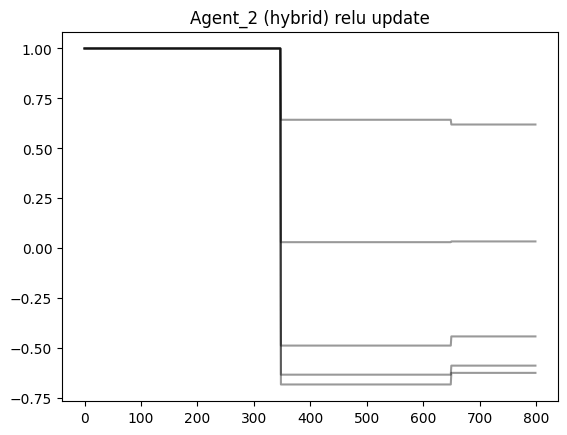

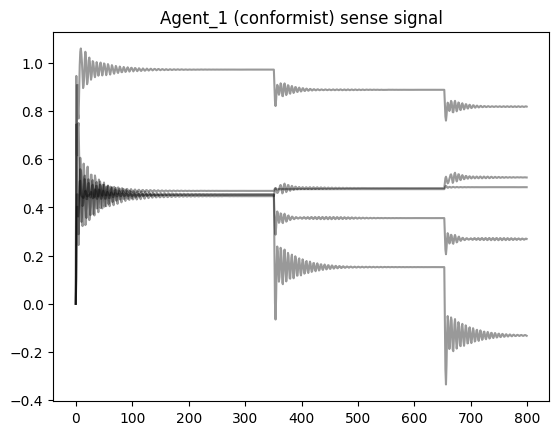

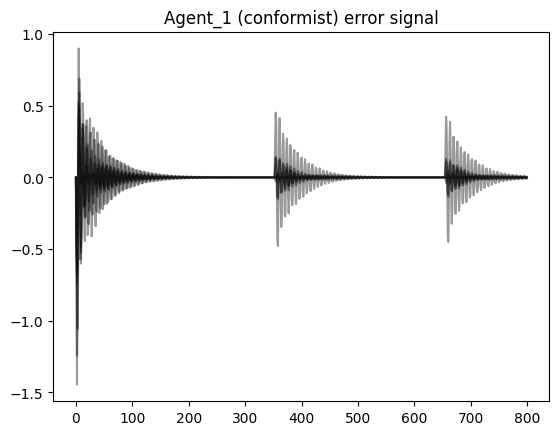

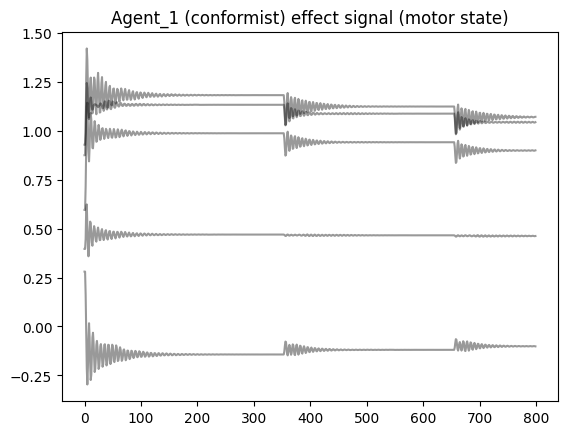

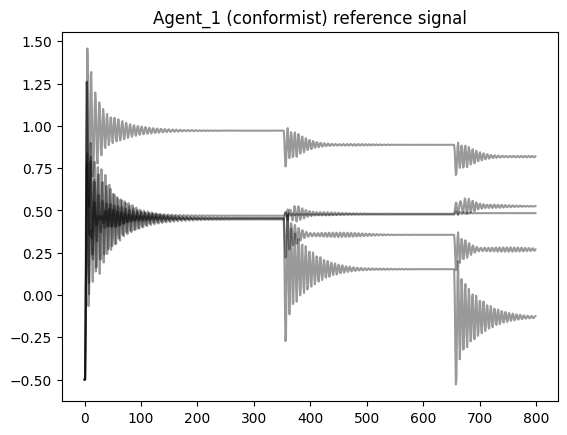

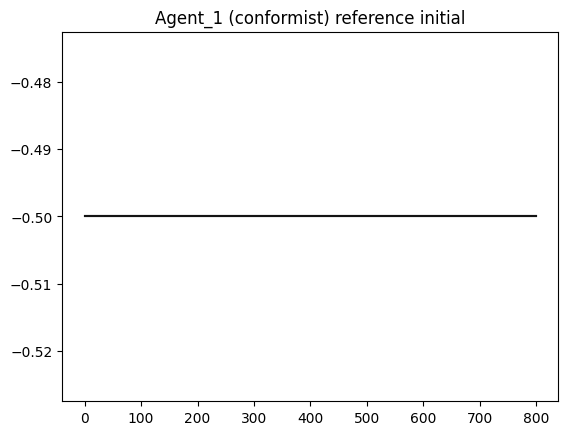

In [6]:
dcn = sys_10_total.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i])
    plt.show()

In [7]:
motor_transform

array([[-0.93898326, -0.1611828 ,  0.7553843 ,  0.42700563, -0.35203536],
       [ 0.53065957, -0.50648638,  0.8650064 , -0.38461259,  0.78798384],
       [-0.97677772, -0.39666925,  0.14947104, -0.19925907, -0.00678947],
       [-0.34635832, -0.42103606,  0.09654856, -0.8288133 , -0.93420927],
       [-0.79114041, -0.90488742,  0.49275316, -0.20776278, -0.52179964]])

In [400]:
np.arange(0,1,1/25).reshape(5,5).T

array([[0.  , 0.2 , 0.4 , 0.6 , 0.8 ],
       [0.04, 0.24, 0.44, 0.64, 0.84],
       [0.08, 0.28, 0.48, 0.68, 0.88],
       [0.12, 0.32, 0.52, 0.72, 0.92],
       [0.16, 0.36, 0.56, 0.76, 0.96]])

In [178]:
tvar = np.random.rand(5)
tvar

array([0.64939399, 0.12925308, 0.52855867, 0.48616132, 0.38479842])

In [182]:
relu_alph = np.random.rand(5) * 2 - 1
relu_alph

array([-0.20543948,  0.2383929 , -0.97144039,  0.9076718 ,  0.48719761])

In [203]:
dual_leaky_relu(tvar, relu_alph)

array([0.13341117, 0.12925308, 0.51346324, 0.48616132, 0.38479842])